# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [83]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [85]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [254]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0,  
    'close_threshold': 2,
    'close_confidence': 1,  
    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 600,

    'k_up': 3,
    'k_down': 2,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [255]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20260101",  # 训练集开始日期
    train_end="20260228",    # 训练集结束日期
    valid_start="20251201",  # 验证集开始日期
    valid_end="20251201",    # 验证集结束日期
    test_start="20251201",   # 测试集开始日期
    test_end="20251231"      # 测试集结束日期
)
'''train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    
    trade_dates,
    test_days_min=23,
    valid_days=1,
    random_seed=6262,
    shuffle=True)'''

总交易日数量: 57
交易日范围: 20251201 ~ 20260227
训练集: 20260105 ~ 20260227 (34天)
验证集: 20251201 ~ 20251201 (1天)
测试集: 20251201 ~ 20251231 (23天)


'train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    \n    trade_dates,\n    test_days_min=23,\n    valid_days=1,\n    random_seed=6262,\n    shuffle=True)'

## 生成训练数据

In [256]:
print("生成训练集样本...")
X_train, y_train , feature_names= samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
训练集样本: X=(26811, 12), y=(26811,)


In [257]:
print("生成验证集样本...")
X_valid, y_valid , __= samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")

生成验证集样本...
20251201: 产生 805 个样本
验证集样本: X=(805, 12), y=(805,)


In [258]:
print("生成测试集样本...")
X_test, y_test ,__= samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20251201: 产生 805 个样本
20251202: 产生 794 个样本
20251203: 产生 791 个样本
20251204: 产生 778 个样本
20251205: 产生 813 个样本
20251208: 产生 803 个样本
20251209: 产生 858 个样本
20251210: 产生 754 个样本
20251211: 产生 807 个样本
20251212: 产生 766 个样本
20251215: 产生 809 个样本
20251216: 产生 865 个样本
20251217: 产生 808 个样本
20251218: 产生 787 个样本
20251219: 产生 769 个样本
20251222: 产生 821 个样本
20251223: 产生 857 个样本
20251224: 产生 803 个样本
20251225: 产生 821 个样本
20251226: 产生 822 个样本
20251229: 产生 821 个样本
20251230: 产生 799 个样本
20251231: 产生 794 个样本
测试集样本: X=(18545, 12), y=(18545,)


## 训练模型

In [259]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

训练 xgboost 模型...
[0]	validation_0-logloss:0.59675
[100]	validation_0-logloss:0.57453
[200]	validation_0-logloss:0.56242
[300]	validation_0-logloss:0.55486
[400]	validation_0-logloss:0.55106
[500]	validation_0-logloss:0.54936
[600]	validation_0-logloss:0.54781
[700]	validation_0-logloss:0.54720
[800]	validation_0-logloss:0.54708
[900]	validation_0-logloss:0.54685
[1000]	validation_0-logloss:0.54630
[1100]	validation_0-logloss:0.54700
[1200]	validation_0-logloss:0.54702
[1300]	validation_0-logloss:0.54724
[1400]	validation_0-logloss:0.54739
[1500]	validation_0-logloss:0.54829
[1600]	validation_0-logloss:0.54855
[1700]	validation_0-logloss:0.54913
[1800]	validation_0-logloss:0.54941
[1900]	validation_0-logloss:0.54987
[1999]	validation_0-logloss:0.55066
阈值优化完成: Best Threshold=0.3454, F0.5=0.4493

特征重要性（前10个）:
volatility    0.161247
num_trades    0.113117
alpha_03      0.102666
alpha_07      0.102089
alpha_02      0.090213
spread        0.075610
WAMP          0.072002
volume        0.06717

In [260]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_dev.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_518880_dev.pkl


## 测试模型

测试集准确率: 0.6426

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.66      0.72     13013
           1       0.43      0.60      0.50      5532

    accuracy                           0.64     18545
   macro avg       0.61      0.63      0.61     18545
weighted avg       0.69      0.64      0.66     18545

测试集准确率: 0.6095

分类报告:
              precision    recall  f1-score   support

           0       0.82      0.61      0.70     14019
           1       0.33      0.59      0.43      4526

    accuracy                           0.61     18545
   macro avg       0.58      0.60      0.57     18545
weighted avg       0.70      0.61      0.64     18545


PR曲线AUC: 0.3599
平均精度 (AP): 0.3600

预测概率统计:
  均值: 0.3305
  标准差: 0.1517
  最小值: 0.0105
  25%分位数: 0.2264
  中位数: 0.3208
  75%分位数: 0.4262
  最大值: 0.9066

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.3113, 标准差=0.1467
  标签1 (正类): 均值=0.3900, 标准差=0.1514


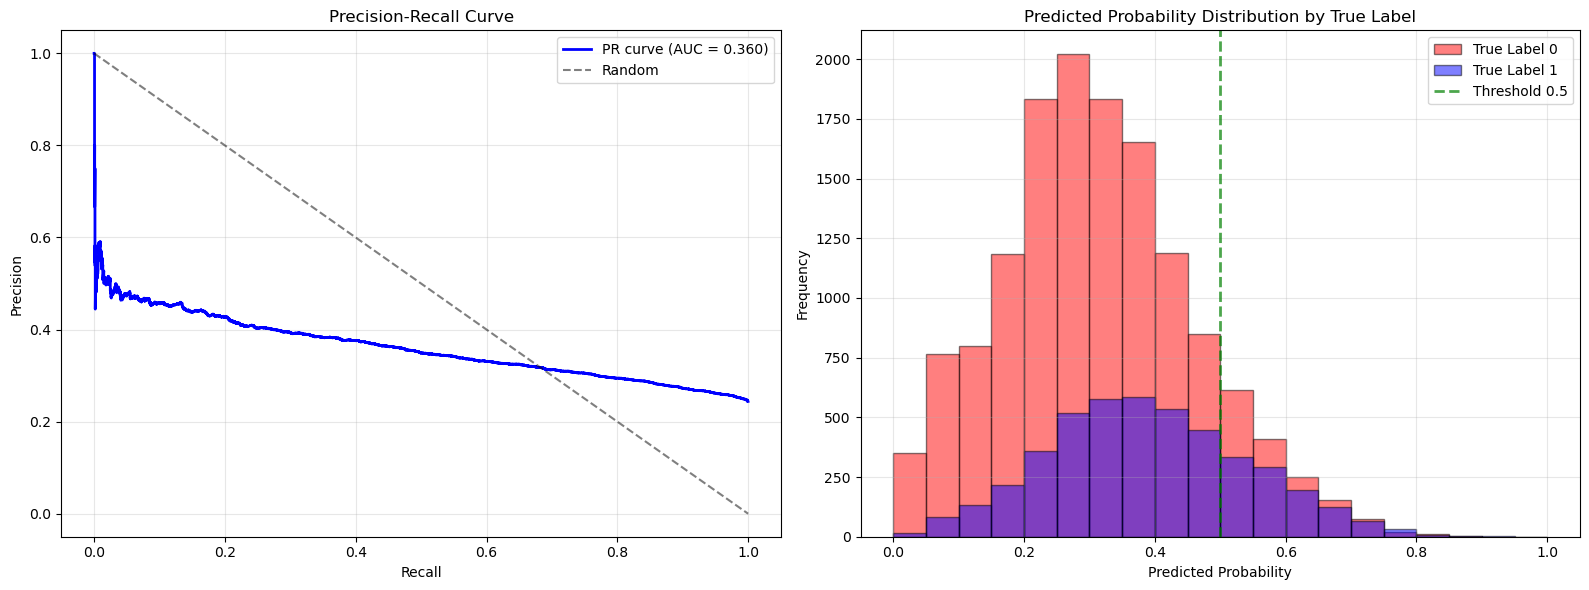

In [261]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [262]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_dev.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 23 个有数据的交易日
-> 过滤掉 8 个无数据日期: ['20251206', '20251207', '20251213', '20251214', '20251220', '20251221', '20251227', '20251228']
-> 回测标的: 518880 (20251201 - 20251231)
-> 任务分配: 共 23 天，使用 4 个核心并行计算...


[SpawnPoolWorker-136] 日期 20251225 完成 | 盈亏: 5.30 | 成交: 10次 | 胜率: 70.0% | 平均持仓: 1263.1快照
[SpawnPoolWorker-133] 日期 20251209 完成 | 盈亏: 2.50 | 成交: 12次 | 胜率: 33.3% | 平均持仓: 1016.6快照
[SpawnPoolWorker-135] 日期 20251217 完成 | 盈亏: 3.20 | 成交: 13次 | 胜率: 46.1% | 平均持仓: 941.9快照
[SpawnPoolWorker-134] 日期 20251201 完成 | 盈亏: -2.10 | 成交: 14次 | 胜率: 28.6% | 平均持仓: 680.0快照
[SpawnPoolWorker-133] 日期 20251210 完成 | 盈亏: -1.50 | 成交: 16次 | 胜率: 37.5% | 平均持仓: 760.6快照
[SpawnPoolWorker-134] 日期 20251202 完成 | 盈亏: 0.30 | 成交: 15次 | 胜率: 40.0% | 平均持仓: 804.3快照
[SpawnPoolWorker-135] 日期 20251218 完成 | 盈亏: -1.30 | 成交: 16次 | 胜率: 25.0% | 平均持仓: 771.6快照
[SpawnPoolWorker-136] 日期 20251226 完成 | 盈亏: -0.60 | 成交: 14次 | 胜率: 35.7% | 平均持仓: 721.6快照
[SpawnPoolWorker-134] 日期 20251203 完成 | 盈亏: -0.50 | 成交: 15次 | 胜率: 26.7% | 平均持仓: 756.2快照
[SpawnPoolWorker-133] 日期 20251211 完成 | 盈亏: 1.20 | 成交: 15次 | 胜率: 33.3% | 平均持仓: 794.7快照
[SpawnPoolWorker-135] 日期 20251219 完成 | 盈亏: 2.40 | 成交: 14次 | 胜率: 50.0% | 平均持仓: 884.8快照
[SpawnPoolWorker-136] 日期 20251229 完成 | 盈亏: 6.60

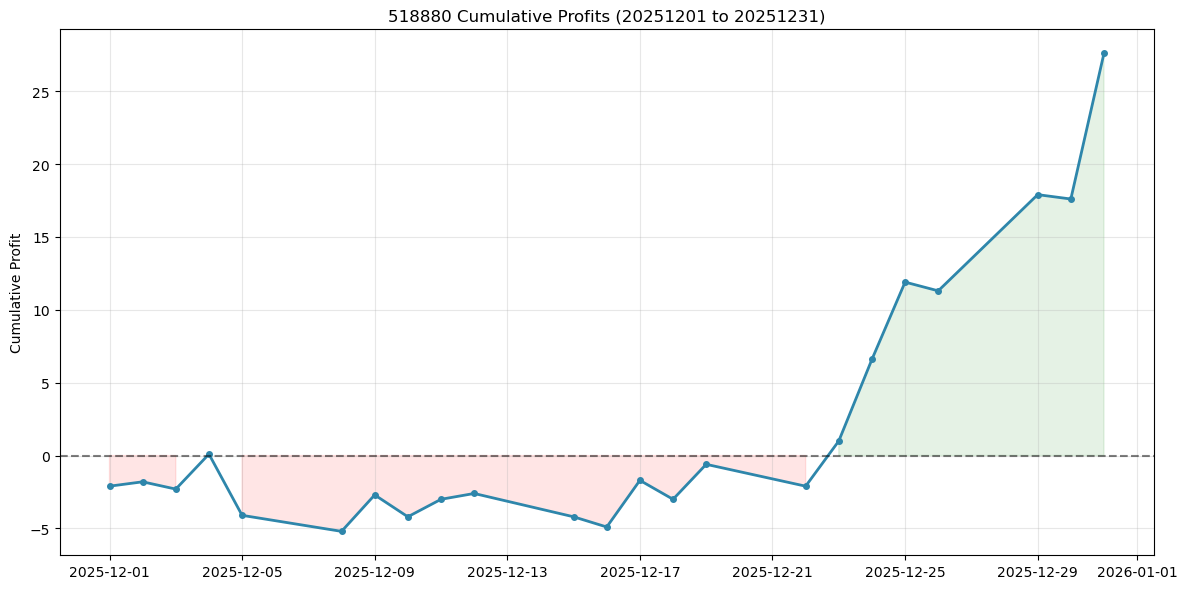


并行回测结果汇总:


In [ ]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 34 个有数据的交易日
-> 过滤掉 331 个无数据日期: ['20260101', '20260102', '20260103', '20260104', '20260110', '20260111', '20260117', '20260118', '20260124', '20260125']...
-> 回测标的: 518880 (20260101 - 20261231)
-> 任务分配: 共 34 天，使用 4 个核心并行计算...


[SpawnPoolWorker-138] 日期 20260116 完成 | 盈亏: -1.20 | 成交: 18次 | 胜率: 27.8% | 平均持仓: 649.4快照
[SpawnPoolWorker-137] 日期 20260105 完成 | 盈亏: -2.60 | 成交: 15次 | 胜率: 20.0% | 平均持仓: 737.4快照
[SpawnPoolWorker-140] 日期 20260211 完成 | 盈亏: -1.40 | 成交: 17次 | 胜率: 29.4% | 平均持仓: 723.4快照
[SpawnPoolWorker-139] 日期 20260129 完成 | 盈亏: 4.80 | 成交: 17次 | 胜率: 47.1% | 平均持仓: 661.1快照
[SpawnPoolWorker-138] 日期 20260119 完成 | 盈亏: -0.50 | 成交: 14次 | 胜率: 21.4% | 平均持仓: 858.6快照
[SpawnPoolWorker-137] 日期 20260106 完成 | 盈亏: 3.00 | 成交: 15次 | 胜率: 20.0% | 平均持仓: 812.5快照
[SpawnPoolWorker-140] 日期 20260212 完成 | 盈亏: -3.90 | 成交: 20次 | 胜率: 30.0% | 平均持仓: 610.4快照
[SpawnPoolWorker-139] 日期 20260130 完成 | 盈亏: 45.70 | 成交: 11次 | 胜率: 54.5% | 平均持仓: 1058.1快照
[SpawnPoolWorker-138] 日期 20260120 完成 | 盈亏: 2.20 | 成交: 12次 | 胜率: 41.7% | 平均持仓: 984.8快照
[SpawnPoolWorker-137] 日期 20260107 完成 | 盈亏: -8.70 | 成交: 21次 | 胜率: 19.1% | 平均持仓: 501.2快照
[SpawnPoolWorker-140] 日期 20260213 完成 | 盈亏: -2.40 | 成交: 16次 | 胜率: 37.5% | 平均持仓: 765.9快照
[SpawnPoolWorker-139] 日期 20260202 完成 | 盈亏: 21

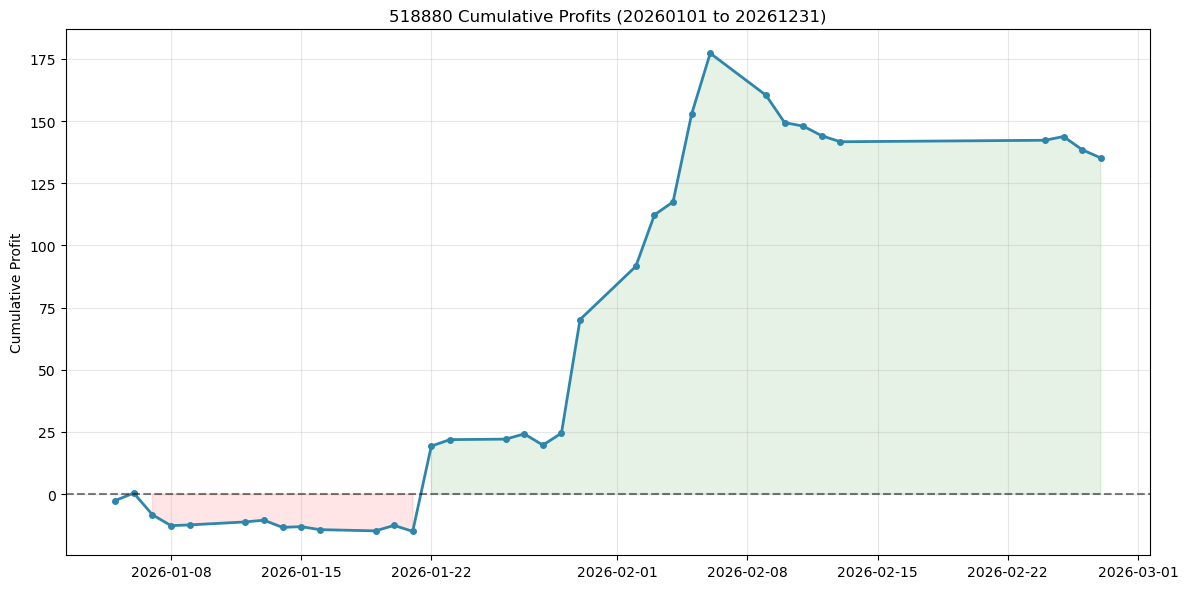


并行回测结果汇总:


In [269]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20260101",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)

In [128]:
print(summary)

{'测试天数': 23, '累计总盈亏': np.float64(46.5), '总成交次数': 190, '盈利交易次数': 75, '亏损交易次数': 115, '加权每手胜率%': np.float64(39.47), '日均盈亏': np.float64(2.02), '胜率(天)%': 60.87, '盈亏比(日均)': np.float64(1.43), '最大单日盈利': 13.6, '最大单日亏损': -8.0, '每笔交易平均盈利': np.float64(0.24), '加权平均持仓时间(快照)': np.float64(1208.3)}


## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    "20251201",
    "20251231",
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
    
)

## 保存回测结果

In [129]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260421_031216
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260421_031216
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [ ]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260414", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_025053
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_042231
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_011936
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_061311

总共删除了 4 个文件夹


## 单日回测观察

In [624]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20260303',StrategyDemo,model_path,param_dict,official = False)


instrument_id 511090
20251201
20251202
20251203
20251204
20251205
20251208
20251209
20251210
20251211
20251212
20251215
20251216
20251217
20251218
20251219
20251222
20251223
20251224
20251225
20251226
20251229
20251230
20251231
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227

instrument_id 511100
20251201
20251202
20251203
20251204
20251205
20251208
20251209
20251210
20251211
20251212
20251215
20251216
20251217
20251218
20251219
20251222
20251223
20251224
20251225
20251226
20251229
20251230
20251231
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20

SystemExit: 

/opt/conda/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


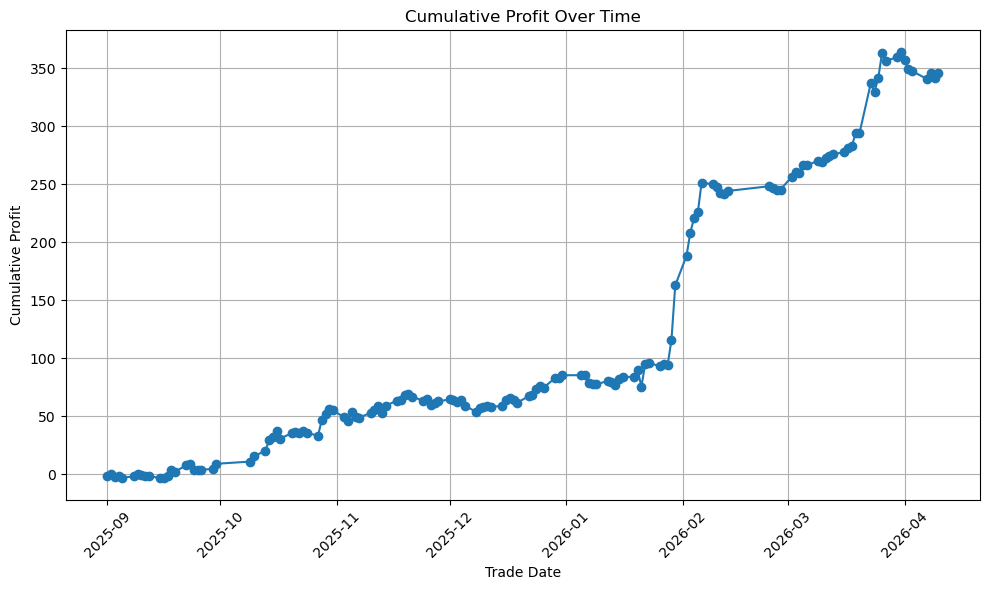

In [266]:
summary = pd.read_csv('/home/jovyan/work/live_trading/518880_20260421_oyyb_02_full.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
